# Análisis del Portafolio de Productos por Usuario

Este notebook analiza la tabla `hey_productos.csv` para identificar saldos disponibles, utilización de crédito y compromisos de deuda.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

# Carga de datos según DICCIONARIO_DATOS
BASE_TXN  = Path(r"/Users/diegodq/Documents/dev/datamoles/Datathon-2026/Datathon_Hey_2026_dataset_transacciones 1/dataset_transacciones")

df_productos = pd.read_csv(BASE_TXN / "hey_productos.csv",
                           dtype={"producto_id": str, "user_id": str},
                           parse_dates=["fecha_apertura", "fecha_ultimo_movimiento"])

df_clientes = pd.read_csv(BASE_TXN / "hey_clientes.csv", dtype={"user_id": str})

# Filtrar productos activos
df_prod = df_productos[df_productos["estatus"] == "activo"].copy()
print(f"Total de productos activos: {len(df_prod):,}")


Total de productos activos: 33,548


## 1. Distribución de tipo_producto

,Conteo,Porcentaje (%)
tipo_producto,,
cuenta_debito,13093,39.027662
tarjeta_credito_hey,6452,19.232145
inversion_hey,4035,12.027543
seguro_vida,2277,6.787290
credito_nomina,1871,5.577084
cuenta_negocios,1226,3.654465
seguro_compras,1157,3.448790
tarjeta_credito_negocios,1013,3.019554
credito_personal,961,2.864552


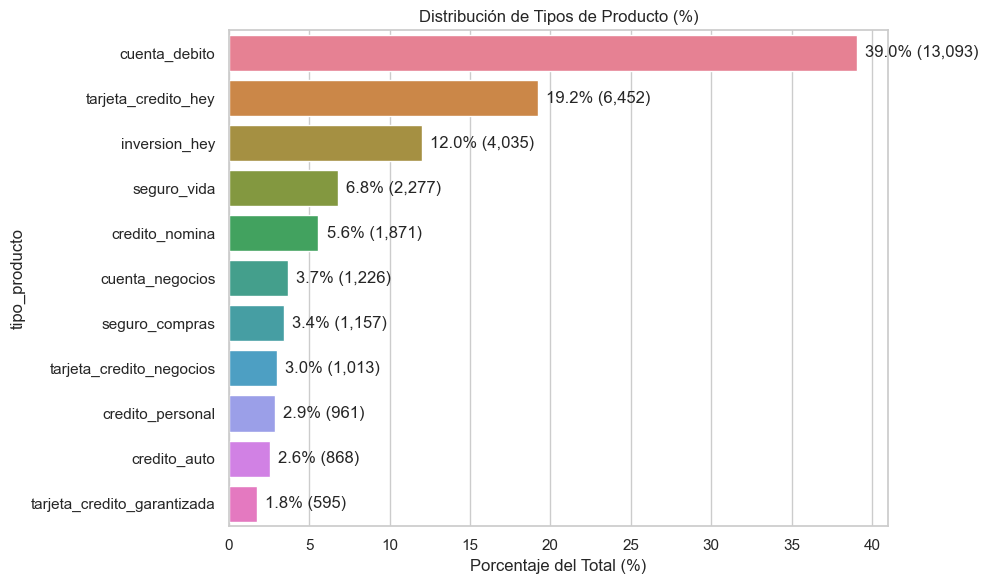

In [2]:
tipo_prod_counts = df_prod['tipo_producto'].value_counts()
tipo_prod_pct = df_prod['tipo_producto'].value_counts(normalize=True) * 100
dist_df = pd.DataFrame({'Conteo': tipo_prod_counts, 'Porcentaje (%)': tipo_prod_pct})
display(dist_df)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=tipo_prod_pct.values, y=tipo_prod_pct.index, hue=tipo_prod_pct.index, legend=False)
plt.title('Distribución de Tipos de Producto (%)')
plt.xlabel('Porcentaje del Total (%)')
for i, v in enumerate(tipo_prod_pct.values):
    ax.text(v + 0.5, i, f'{v:.1f}% ({tipo_prod_counts.values[i]:,})', va='center')
plt.tight_layout()
plt.show()


## 2. % de usuarios que tienen inversion_hey activa (Caso UC1)

In [3]:
total_users = df_prod['user_id'].nunique()
users_with_inversion = df_prod[df_prod['tipo_producto'] == 'inversion_hey']['user_id'].nunique()
pct_inversion = (users_with_inversion / total_users) * 100

print(f"% de usuarios con inversion_hey activa: {pct_inversion:.2f}% ({users_with_inversion:,} de {total_users:,})")

# Cuantificar: ¿qué % de usuarios tiene saldo alternativo disponible en inversion_hey?
inversiones = df_prod[(df_prod["tipo_producto"]=="inversion_hey") & (df_prod["saldo_actual"]>0)]
users_inversion_con_saldo = inversiones['user_id'].nunique()
pct_inversion_con_saldo = (users_inversion_con_saldo / total_users) * 100
print(f"Usuarios con inversión_hey y saldo disponible (>0): {users_inversion_con_saldo:,} ({pct_inversion_con_saldo:.2f}% del total de usuarios con productos activos)")


% de usuarios con inversion_hey activa: 28.40% (4,035 de 14,208)
Usuarios con inversión_hey y saldo disponible (>0): 4,035 (28.40% del total de usuarios con productos activos)


## 3. Distribución de saldo_actual por tipo_producto

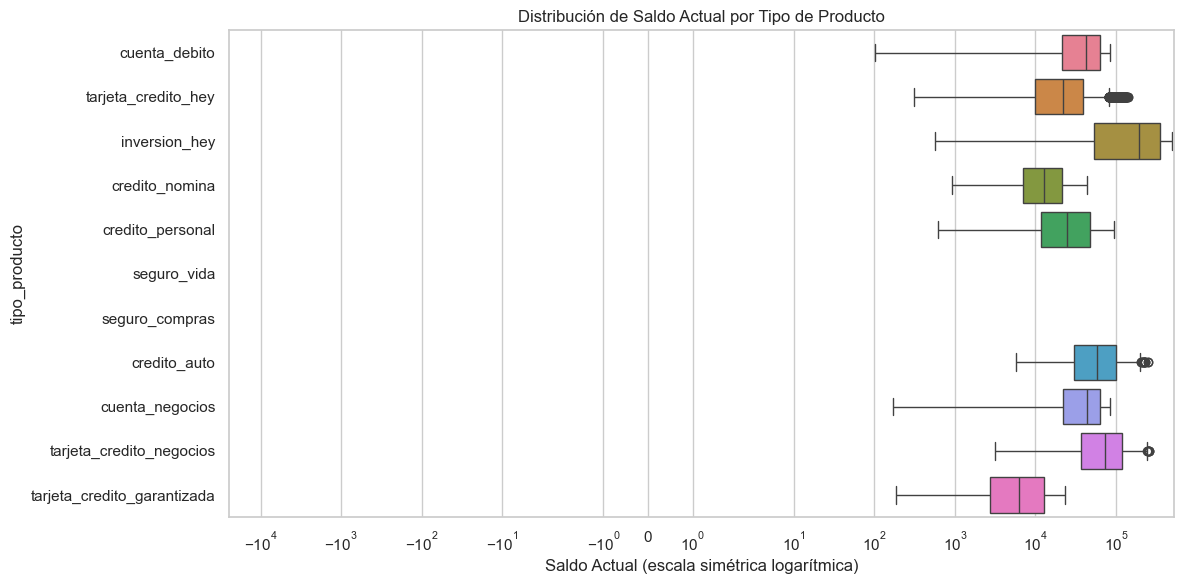

,count,mean,std,min,25%,50%,75%,max
tipo_producto,,,,,,,,
credito_auto,868.0,68962.275000,47709.775773,5804.50,30073.375,57387.15,98564.0250,252534.70
credito_nomina,1871.0,14844.841208,9650.220093,910.50,6990.400,12685.00,21545.0000,43320.00
credito_personal,961.0,31143.995317,23403.036131,615.50,11818.800,24768.00,47287.2000,94759.30
cuenta_debito,13093.0,42374.190877,24543.809094,100.94,21097.850,42247.70,63530.1300,84999.05
cuenta_negocios,1226.0,42729.096517,24200.214922,168.69,21832.345,43301.68,63578.9225,84947.94
inversion_hey,4035.0,209952.874639,155861.717556,565.08,53655.895,193293.46,347793.8550,499905.57
seguro_compras,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seguro_vida,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tarjeta_credito_garantizada,595.0,7878.473109,5983.595871,184.40,2712.200,6202.00,12835.0000,23121.60


In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_prod, x='saldo_actual', y='tipo_producto', hue='tipo_producto', legend=False)
plt.title('Distribución de Saldo Actual por Tipo de Producto')
plt.xscale('symlog')
plt.xlabel('Saldo Actual (escala simétrica logarítmica)')
plt.tight_layout()
plt.show()

display(df_prod.groupby('tipo_producto')['saldo_actual'].describe())


## 4. Distribución de utilizacion_pct para tarjetas de crédito

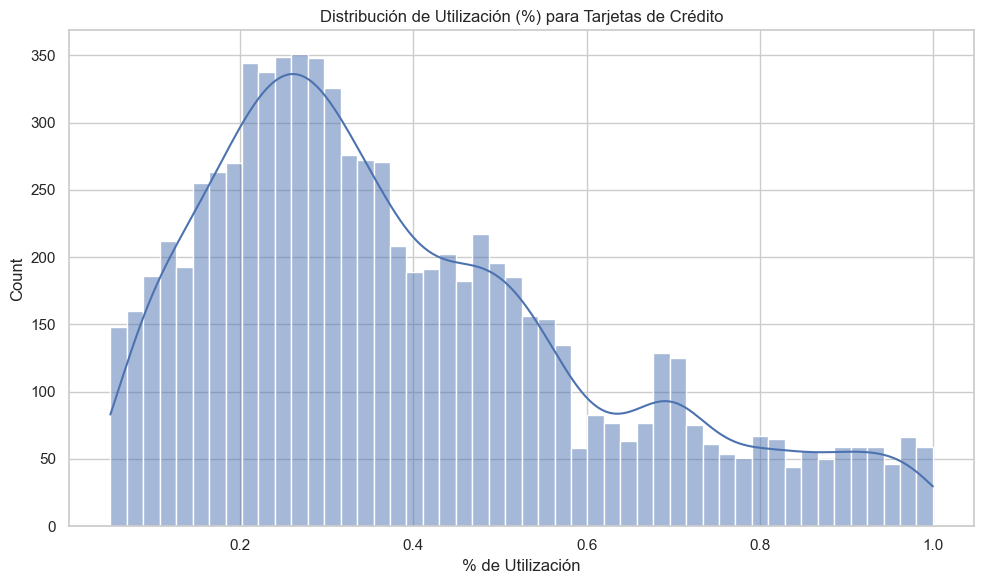

Usuarios con utilización >= 90% (al límite): 0 de 7,960 (0.00%)


In [5]:
tcs = df_prod[df_prod['tipo_producto'].str.contains('tarjeta_credito', case=False, na=False)]

plt.figure(figsize=(10, 6))
sns.histplot(data=tcs, x='utilizacion_pct', bins=50, kde=True)
plt.title('Distribución de Utilización (%) para Tarjetas de Crédito')
plt.xlabel('% de Utilización')
plt.tight_layout()
plt.show()

al_limite = tcs[tcs['utilizacion_pct'] >= 90]
total_tcs_users = tcs['user_id'].nunique()
if total_tcs_users > 0:
    pct = (al_limite['user_id'].nunique() / total_tcs_users) * 100
    print(f"Usuarios con utilización >= 90% (al límite): {al_limite['user_id'].nunique():,} de {total_tcs_users:,} ({pct:.2f}%)")
else:
    print("No hay usuarios con este tipo de producto.")


## 5. Distribución de monto_mensualidad para productos de préstamo

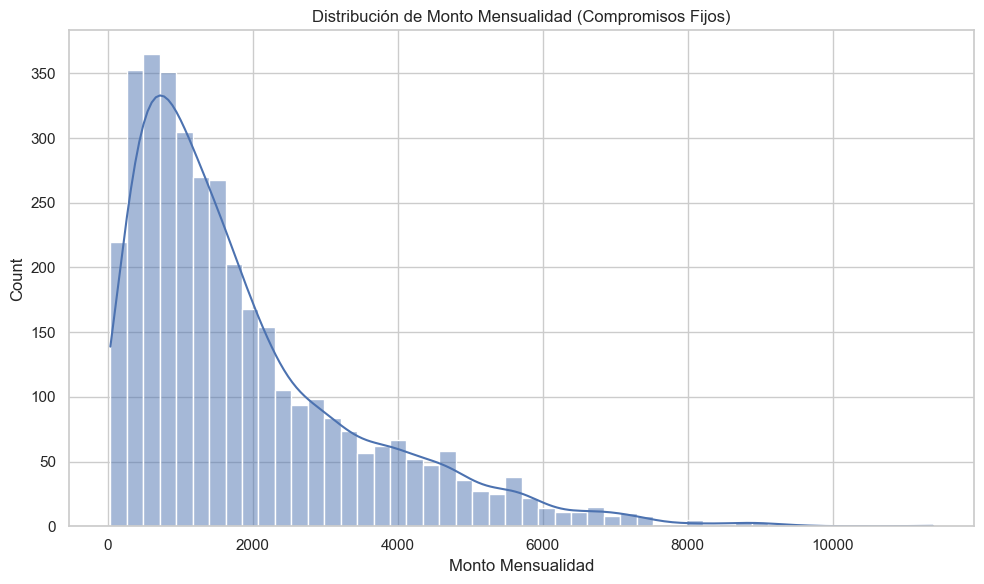

Mediana de compromisos mensuales de deuda: 1,377.12


In [6]:
prestamos = df_prod[df_prod['monto_mensualidad'] > 0]

plt.figure(figsize=(10, 6))
sns.histplot(data=prestamos, x='monto_mensualidad', bins=50, kde=True)
plt.title('Distribución de Monto Mensualidad (Compromisos Fijos)')
plt.xlabel('Monto Mensualidad')
plt.tight_layout()
plt.show()

mediana_deuda = prestamos['monto_mensualidad'].median()
print(f"Mediana de compromisos mensuales de deuda: {mediana_deuda:,.2f}")


## 6. Promedio de num_productos_activos por usuario

In [7]:
productos_por_usuario = df_prod.groupby('user_id').size().reset_index(name='num_productos_activos')
# Uniendo con clientes por si hay clientes sin productos activos
clientes_prod = pd.merge(df_clientes[['user_id']], productos_por_usuario, on='user_id', how='left').fillna(0)

promedio_prod = clientes_prod['num_productos_activos'].mean()
print(f"Promedio de productos activos por usuario: {promedio_prod:.2f}")


Promedio de productos activos por usuario: 2.23


## 7. Usuarios con inversion_hey Y cuenta_debito simultáneamente

In [8]:
users_inversion = set(df_prod[df_prod['tipo_producto'] == 'inversion_hey']['user_id'])
users_debito = set(df_prod[df_prod['tipo_producto'] == 'cuenta_debito']['user_id'])
users_ambos = users_inversion.intersection(users_debito)

print(f"Usuarios con inversion_hey Y cuenta_debito simultáneamente: {len(users_ambos):,} ({(len(users_ambos)/total_users)*100:.2f}% del total con productos)")


Usuarios con inversion_hey Y cuenta_debito simultáneamente: 3,664 (25.79% del total con productos)
